## flower_arc

In [4]:
import matplotlib.pyplot as plt
import numpy as np

 ## flower_petal

In [5]:
from cprdspy.CPR_matplotlib.Arcs.arc import arc
import numpy as np


def flower_petal(
    R=1,
    r=1,
    n=4,
    rotation=0,
    color="#0f0",
    alpha=1,
    center=(0, 0),
    points=1000,
    linestyle="-",
    linewidth=1,
    label=None,
    marker=None,
    markersize=5,
    markerfacecolor="r",
    markeredgecolor="k",
    markeredgewidth=1,
    ax=None,
    plot_center=False,
    center_color="#0f0",
    center_size=8,
    use_degree=True,  # 默认使用角度制输入
    plot=True,
    direction="ccw",
    return_petal=False,
    **kwargs,
):
    """
    绘制一片花瓣。
    rotation: 如果 use_degree=True，则以度为单位；否则以弧度为单位。
    内部所有三角计算使用弧度（theta），传递给 arc 的角度参数应为不含旋转的基角，
    并把旋转通过 rotation 参数单独传给 arc（避免重复旋转）。
    """
    # 基本参数（弧度）
    angle = 2 * np.pi / n
    a = R * np.sin(np.pi / n)
    if r > 0:
        beta = np.arccos(min(1, max(-1, (a) / r)))  # 限制在[-1,1]范围内
    else:
        beta = 0
    theta_arc = np.pi / 2 - np.pi / n + np.arccos(min(1, max(-1, (a) / r)))

    # 将输入 rotation 转为弧度以便做三角运算
    rotation_rad = np.deg2rad(rotation) if use_degree else rotation

    # 计算基角（不包含 rotation）——这些是 arc 的 angle1/angle2 基本值
    center1_theta = rotation_rad + angle / 2
    center2_theta = rotation_rad - angle / 2

    # 计算圆心坐标（使用 rotation_rad 定位圆心）
    center1 = (
        np.cos(center1_theta) * R + center[0],
        np.sin(center1_theta) * R + center[1],
    )
    center2 = (
        np.cos(center2_theta) * R + center[0],
        np.sin(center2_theta) * R + center[1],
    )

    # 角度计算（相对于各自圆心的起始和结束角度）
    if abs(r - a) < 1e-12:
        # 特殊情况：r = a
        theta1_base_rad = np.pi + angle / 2
        theta2_base_rad = np.pi + angle / 2 + theta_arc
        theta3_base_rad = np.pi / 2
        theta4_base_rad = np.pi / 2 + theta_arc
    elif r > a:
        # 一般情况：r > a
        theta1_base_rad = np.pi + angle / 2
        theta2_base_rad = np.pi + angle / 2 + theta_arc
        theta3_base_rad = np.pi / 2 - beta
        theta4_base_rad = np.pi / 2 - beta + theta_arc
    else:
        print("r=", r, ",a=", a)
        print(f"r<a,不能形成花瓣。最小需要 r > {a:.3f}")
        return None

    # 传给 arc 的角度参数：如果 use_degree，需要把基角从弧度转换为度数；
    # rotation_for_arc 则传入原始输入（度或弧度），由 arc 内部统一处理
    if use_degree:
        theta1 = np.rad2deg(theta1_base_rad)
        theta2 = np.rad2deg(theta2_base_rad)
        theta3 = np.rad2deg(theta3_base_rad)
        theta4 = np.rad2deg(theta4_base_rad)
        rotation_for_arc = rotation  # 原始度数
    else:
        theta1 = theta1_base_rad
        theta2 = theta2_base_rad
        theta3 = theta3_base_rad
        theta4 = theta4_base_rad
        rotation_for_arc = rotation_rad  # 弧度

    # 只有在需要绘制时才导入 matplotlib
    if plot:
        import matplotlib.pyplot as plt

        if ax is None:
            ax = plt.gca()

    arc_d1 = None
    arc_d2 = None

    # 选择绘制分支（传入的角度和 rotation_for_arc 已与 use_degree 匹配）
    if abs(r - a) < 1e-12 or r > a:
        arc_d1 = arc(
            r,
            theta1,
            theta2,
            rotation_for_arc,
            color,
            alpha,
            center1,
            points,
            linestyle,
            linewidth,
            label,
            marker,
            markersize,
            markerfacecolor,
            markeredgecolor,
            markeredgewidth,
            ax,
            use_degree,
            plot,
            direction,
            return_petal,
            **kwargs,
        )
        arc_d2 = arc(
            r,
            theta3,
            theta4,
            rotation_for_arc,
            color,
            alpha,
            center2,
            points,
            linestyle,
            linewidth,
            label,
            marker,
            markersize,
            markerfacecolor,
            markeredgecolor,
            markeredgewidth,
            ax,
            use_degree,
            plot,
            direction,
            return_petal,
            **kwargs,
        )

    # 画圆心（用于调试）
    if plot_center and plot:
        import matplotlib.pyplot as plt

        plt.scatter(
            center1[0], center1[1], color=center_color, s=center_size, alpha=alpha
        )
        plt.scatter(
            center2[0], center2[1], color=center_color, s=center_size, alpha=alpha
        )

    # 如果不绘制但需要返回花瓣数据
    if not plot and arc_d1 is not None and arc_d2 is not None:
        return (center1[0], center1[1]), (center2[0], center2[1]), arc_d1, arc_d2
    

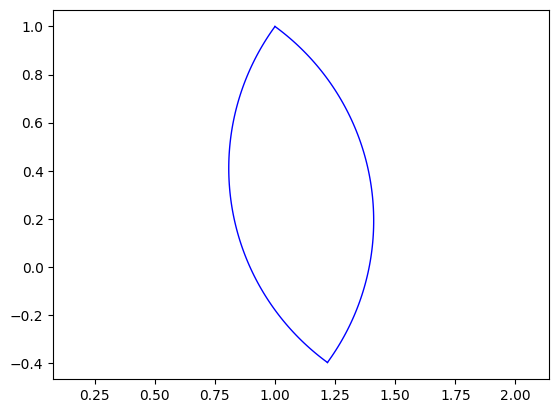

In [6]:
# 测试调用
flower_petal(
    1,
    1,
    4,
    30,
    "b",
    1,
    (1, 1),
    100,
    "-",
    1,
    plot_center=False,
    center_size=5,
    use_degree=False,
)

In [7]:
def flower(
    R=1,
    r=1,
    n=4,
    N=12,
    rotation=0,
    color="#0f0",
    alpha=1,
    center=(0, 0),
    points=1000,
    linestyle="-",
    linewidth=1,
    label=None,
    marker=None,
    markersize=5,
    markerfacecolor="r",
    markeredgecolor="k",
    markeredgewidth=1,
    ax=None,
    plot_center=False,
    center_color="#0f0",
    center_size=8,
    use_degree=True,
    plot=True,
    direction="ccw",
    return_petal=False,
    **kwargs,
):
    for i in range(N):
        flower_petal(
            R,
            r,
            n,
            (
                rotation + i * 360 / N + 90
                if use_degree
                else i * 2 * np.pi / N + np.pi / 2
            ),
            color,
            alpha,
            center,
            points,
            linestyle,
            linewidth,
            label,
            marker,
            markersize,
            markerfacecolor,
            markeredgecolor,
            markeredgewidth,
            ax,
            plot_center,
            center_color,
            center_size,
            use_degree,
            plot,
            direction,
            return_petal,
            **kwargs,
        )

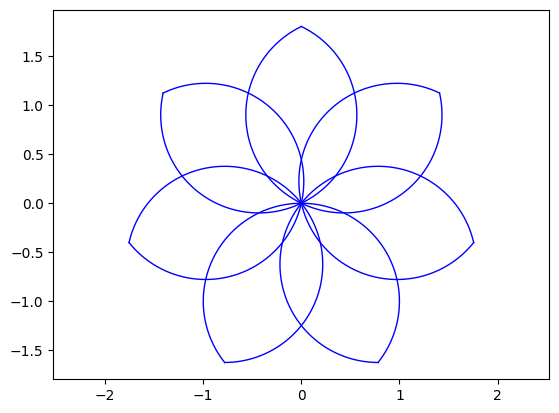

In [17]:
flower(R=1, r=1, n=7, N=7, color="b", center=(0, 0))

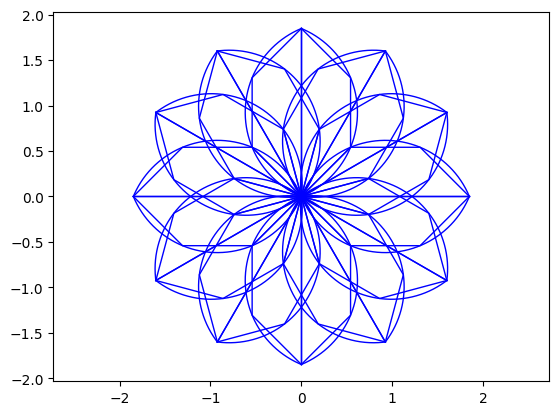

In [9]:
flower(R=1, r=1, n=8, color="b", center=(0, 0),points=2)
flower(R=1, r=1, n=8, color="b", center=(0, 0),points=4)
flower(R=1, r=1, n=8, color="b", center=(0, 0),points=1000)

In [10]:
def flowers(
    R=1,
    r=1,
    n=4,
    ratio=np.sqrt(2),
    M=3,
    N=12,
    color="b",
    alpha=1,
    theta=0,
    center=(0, 0),
    points=1000,
    linestyle="-",
    linewidth=1,
    label=None,
    marker=None,
    markersize=5,
    markerfacecolor="r",
    markeredgecolor="b",
    markeredgewidth=1,
    ax=None,
    plot_center=False,
    center_color="r",
    center_size=5,
    use_degree=False,
    plot=True,
    direction="ccw",
    return_flower=False,
    **kwargs,
):
    for j in range(1, M + 1):
        for i in range(0, N):
            flower_petal(
                R * (ratio ** (j - 1)),
                r * (ratio ** (j - 1)),
                n,
                2 * i * np.pi / N + (j - 1) * np.pi / N + theta+np.pi/2,
                color,
                alpha,
                center,
                points,
                linestyle,
                linewidth,
                label,
                marker,
                markersize,
                markerfacecolor,
                markeredgecolor,
                markeredgewidth,
                ax,
                plot_center,
                center_color,
                center_size,
                use_degree,
                plot,
                direction,
                return_flower,
                **kwargs,
            )

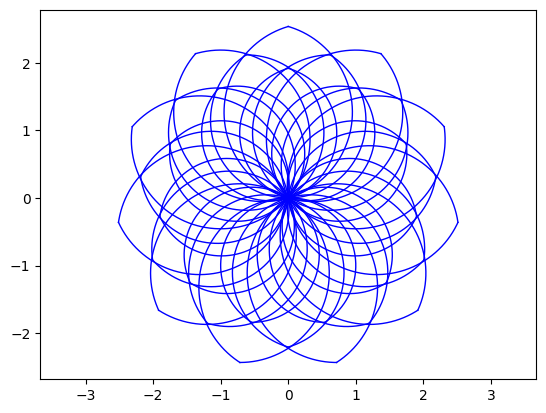

In [11]:
flowers(1,1,11,1.15,3,11,points=100000)

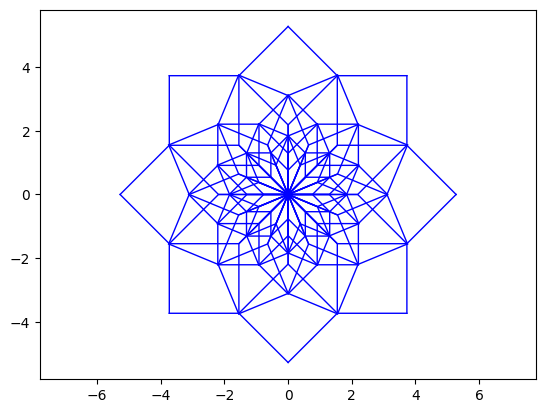

In [12]:
# flowers(1,1,4,1.6,3,12,points=100000
flowers(1,1,8,1.3,5,8,points=4)

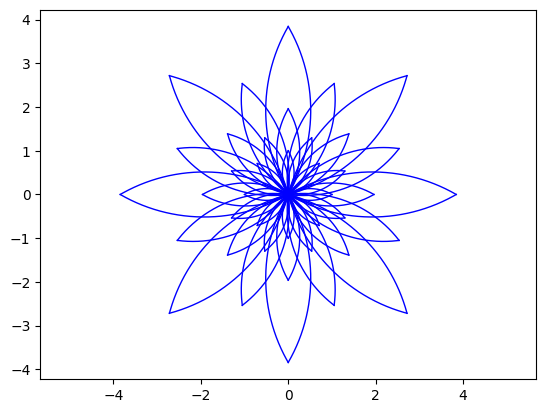

In [13]:
flowers(1,1,3,1.4,5,8)

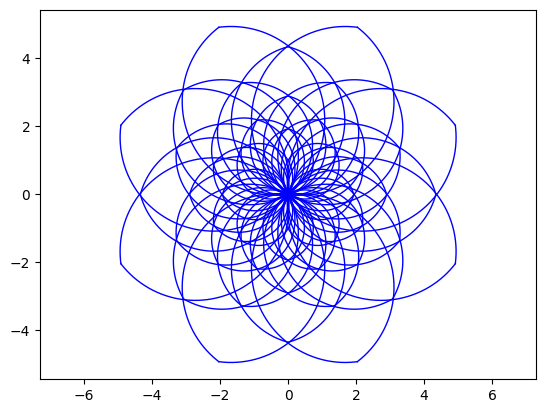

In [14]:
# ax, fig = plt.subplots(figsize=(3, 3), dpi=200)
flowers(1,1,12,np.sqrt(1.5),6,8,direction="ccw")
# flowers(1,1,6,np.sqrt(1.5),3,12,points=2)
# flowers(1,1,6,np.sqrt(1.5),3,12,points=3)

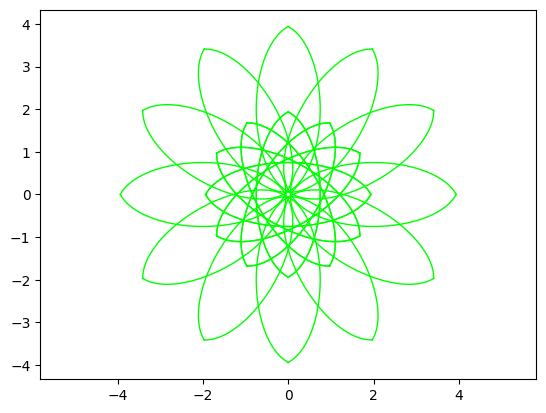

In [15]:
from flower import *
oval_flower_a(2, 1, 0.5, n=12, center=(0, 0))
# oval_flower_a(2, 1, 0.5, n=12, center=(0, 0),points=4)
oval_flower(2, 1, 0.5, n=12, center=(0, 0))
# oval_flower(2, 1, 0.5, n=12, center=(0, 0),points=3)

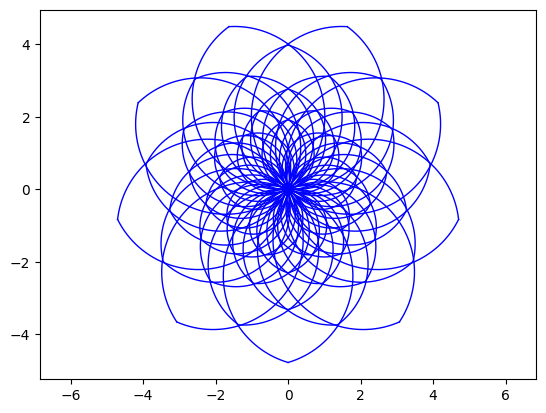

In [16]:
flowers(1,1,11,1.2,6,9)

In [ ]:
from flower import *
flowers(
    R=1,
    r=1,
    n=4,
    ratio=np.sqrt(2),
    M=3,
    N=12,
    color="#0F0",
    alpha=1,
    theta=0,
    center=(0, 0),
    linestyle="-",
    linewidth=1,
    points=4,
)